In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets



In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")


In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 50
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 100
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]
[7.  3.2 4.7 1.4]
1
[0 1 0]
[6.3 3.3 6.  2.5]
2
[0 0 1]


In [4]:
#Topology: 4 x 3 x 3 x 3 x 3
input_size_layer1 = 4
num_neurons_layer1 = 3

input_size_layer2 = num_neurons_layer1
num_neurons_layer2 = 3

input_size_layer3 = num_neurons_layer2
num_neurons_layer3 = 3

input_size_layer4 = num_neurons_layer3
num_neurons_layer4 = 3

layer1 = list()
layer2 = list()
layer3 = list()
layer4 = list()

# Define the current architecture (Input, Hidden, Hidden, Hidden, Output) for plotting
current_architecture = [input_size_layer1, num_neurons_layer1, num_neurons_layer2, num_neurons_layer3, num_neurons_layer4]

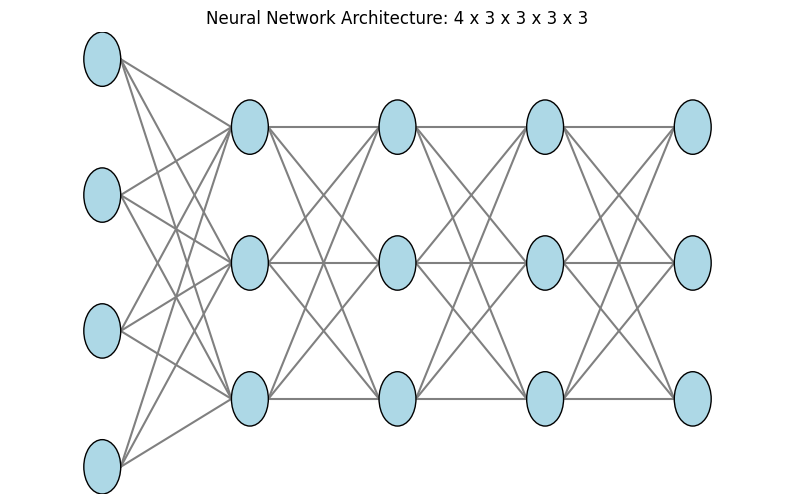

In [5]:
def draw_neural_net(ax, layer_sizes):
    v_spacing = 0.5
    h_spacing = 0.8
    node_size = 0.10

    # Calculate positions for each neuron
    for i, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2.0
        for j in range(layer_size):
            circle = plt.Circle((i * h_spacing, layer_top - j * v_spacing), node_size, color='lightblue', ec='black', zorder=4)
            ax.add_artist(circle)

    # Draw connections
    for i in range(len(layer_sizes) - 1):
        layer1_size = layer_sizes[i]
        layer2_size = layer_sizes[i+1]

        layer1_top = v_spacing * (layer1_size - 1) / 2.0
        layer2_top = v_spacing * (layer2_size - 1) / 2.0

        for j in range(layer1_size):
            for k in range(layer2_size):
                line = plt.Line2D([i * h_spacing + node_size, (i + 1) * h_spacing - node_size],
                                  [layer1_top - j * v_spacing, layer2_top - k * v_spacing], c='gray', zorder=1)
                ax.add_artist(line)

    # Set limits and hide axes
    ax.set_xlim(-0.5, len(layer_sizes) * h_spacing - h_spacing + 0.5)
    ax.set_ylim(-(v_spacing * (max(layer_sizes) - 1) / 2.0) - node_size, (v_spacing * (max(layer_sizes) - 1) / 2.0) + node_size)
    ax.axis('off')

# Define the current architecture (Input, Hidden, Hidden, Hidden, Output)
#current_architecture = [input_size_layer1, num_neurons_layer1, num_neurons_layer2, num_neurons_layer3, num_neurons_layer4]

# Create the plot
fig = plt.figure(figsize=(10, 6))
ax = fig.gca()
ax.set_title('Neural Network Architecture: {} x {} x {} x {} x {}'.format(current_architecture[0], current_architecture[1], current_architecture[2], current_architecture[3], current_architecture[4]))
draw_neural_net(ax, current_architecture)
plt.show()

In [6]:
def generate_weights(num_weights):
  w = np.zeros(num_weights)
  for i in range(len(w)):
    w[i] = (np.random.rand() - 0.5)
  return w

def init_weights():
  layer1.clear()
  layer2.clear()
  layer3.clear()
  layer4.clear()

#inicializacion de pesos
  for i in range(num_neurons_layer1):
    layer1.append( generate_weights(input_size_layer1+1)) # plus 1 -> plus bias
  for i in range(num_neurons_layer2):
    layer2.append( generate_weights(input_size_layer2+1)) # plus 1 -> plus bias
  for i in range(num_neurons_layer3):
    layer3.append( generate_weights(input_size_layer3+1)) # plus 1 -> plus bias
  for i in range(num_neurons_layer4):
    layer4.append( generate_weights(input_size_layer4+1)) # plus 1 -> plus bias

def net_input(input_vector, w):
  net_input_var = w[0]
  for i in range(len(input_vector)):
    net_input_var += w[i+1] * input_vector[i]
  return net_input_var

def sigmoid(z):
  activation = 1/(1+np.power(np.e, -z))
  return activation

def propagate(X, w):
  neuronInput = net_input(X, w) # Sigma
  neuronOutput = sigmoid(neuronInput) # sigma
  return neuronOutput

#Loss function
def calculate_error():
  total_err = 0
  for idx in range(len(X)):
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[idx], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

#Calculo de salidas de las nuevas capas
    output_layer3 = np.zeros(num_neurons_layer3)
    for i in range(len(output_layer3)):
      output_layer3[i] = propagate(output_layer2, layer3[i])


    output_layer4 = np.zeros(num_neurons_layer4)
    for i in range(len(output_layer4)):
      output_layer4[i] = propagate(output_layer3, layer4[i])

    err = Y[idx] - output_layer4
    err = np.power(err,2)
    err = err.sum()
    total_err += err

  return total_err / ( len(X) )

In [7]:
print(generate_weights(5))

[-0.21330174  0.15459358 -0.01756919 -0.26203961 -0.39856631]


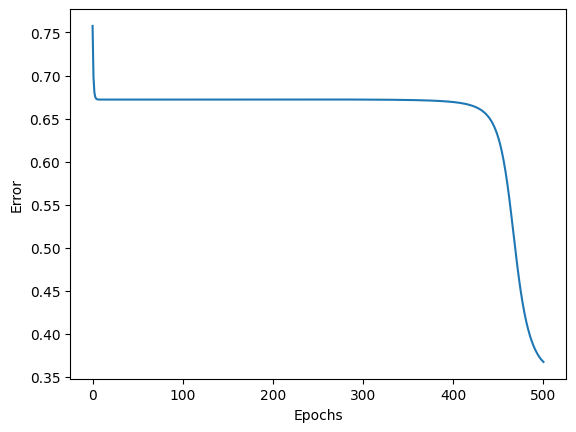

In [8]:
alpha = 0.03
epochs = 500

init_weights()

E = list()
E.append( calculate_error() )
for e in range(epochs):
  for d in range(len(X)):
    # Etapa 1 - Propagación
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[d], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

    output_layer3 = np.zeros(num_neurons_layer3)
    for i in range(len(output_layer3)):
      output_layer3[i] = propagate(output_layer2, layer3[i])

    output_layer4 = np.zeros(num_neurons_layer4)
    for i in range(len(output_layer4)):
      output_layer4[i] = propagate(output_layer3, layer4[i])

    # Etapa 2 - Retropropagación de los errores
    delta_layer4 = np.zeros(num_neurons_layer4)
    for i in range(len(delta_layer4)):
      delta_layer4[i] = output_layer4[i] * (1 - output_layer4[i]) * (Y[d][i] - output_layer4[i])

    for i in range(len(layer4)):
      layer4[i][0] += alpha * delta_layer4[i] * 1
      for j in range(len(layer4[i])-1):
        layer4[i][j+1] += alpha * delta_layer4[i] * output_layer3[j]

    delta_layer3 = np.zeros(num_neurons_layer3)
    for i in range(len(delta_layer3)):
      weighted_delta_errors = 0
      for j in range(num_neurons_layer4):
        weighted_delta_errors += layer4[j][i+1] * delta_layer4[j]
      delta_layer3[i] = output_layer3[i] * (1 - output_layer3[i]) * weighted_delta_errors

    for i in range(len(layer3)):
      layer3[i][0] += alpha * delta_layer3[i] * 1
      for j in range(len(layer3[i])-1):
        layer3[i][j+1] += alpha * delta_layer3[i] * output_layer2[j]

    delta_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(delta_layer2)):
      weighted_delta_errors = 0
      for j in range(num_neurons_layer3):
        weighted_delta_errors += layer3[j][i+1] * delta_layer3[j]
      delta_layer2[i] = output_layer2[i] * (1 - output_layer2[i]) * weighted_delta_errors

    for i in range(len(layer2)):
      layer2[i][0] += alpha * delta_layer2[i] * 1
      for j in range(len(layer2[i])-1):
        layer2[i][j+1] += alpha * delta_layer2[i] * output_layer1[j]

    delta_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(delta_layer1)):
      weighted_delta_errors = 0
      for j in range(num_neurons_layer2):
        weighted_delta_errors += layer2[j][i+1] * delta_layer2[j]
      delta_layer1[i] = output_layer1[i] * (1 - output_layer1[i]) * weighted_delta_errors

    for i in range(len(layer1)):
      layer1[i][0] += alpha * delta_layer1[i] * 1
      for j in range(len(layer1[i])-1):
        layer1[i][j+1] += alpha * delta_layer1[i] * X[d][j]

  E.append( calculate_error() )

Error_vec = np.asarray(E)
plt.plot(Error_vec)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

## Arquitectura de la Red Neuronal

### Topología
La red neuronal actual tiene una arquitectura de **4x3x3x3x3**, lo que significa:
*   **Capa de Entrada:** 4 neuronas (recibiendo 4 características del conjunto de datos Iris).
*   **Primera Capa Oculta:** 3 neuronas.
*   **Segunda Capa Oculta:** 3 neuronas.
*   **Tercera Capa Oculta:** 3 neuronas.
*   **Capa de Salida:** 3 neuronas (correspondiente a las 3 clases de salida del conjunto de datos Iris).

### Inicialización de Pesos
Los pesos de la red neuronal se inicializan aleatoriamente para cada conexión. La función `init_weights()` (en la celda `xw-bXrN6uvpv`) es responsable de esto:
*   Borra las listas de pesos existentes para cada capa (`layer1`, `layer2`, `layer3`, `layer4`).
*   Para cada neurona en cada capa, se llama a la función `generate_weights()` para crear un vector de pesos. Estos pesos incluyen un término de *bias* (sesgo), por lo que se genera `input_size_layerX + 1` pesos para cada neurona. Los valores de los pesos están entre -0.5 y 0.5.

### Propagación Hacia Adelante (Forward Propagation)
La propagación hacia adelante calcula la salida de la red para una entrada dada. Esto se realiza en la función `calculate_error()` (celda `xw-bXrN6uvpv`) y dentro del ciclo de entrenamiento (celda `tT4v0koYxxOn`):
1.  **Cálculo de la entrada neta:** Para cada neurona, la función `net_input()` multiplica la entrada por sus pesos correspondientes y suma un término de bias.
2.  **Activación:** La función `sigmoid()` se aplica a la entrada neta para producir la salida de la neurona. Esta función de activación es utilizada en todas las capas ocultas y de salida.
3.  El proceso se repite secuencialmente para `output_layer1`, `output_layer2`, `output_layer3` y `output_layer4`.

### Entrenamiento
El entrenamiento de la red neuronal se realiza mediante el algoritmo de **retropropagación** (backpropagation) y se define en la celda `tT4v0koYxxOn`:
*   **Parámetros:** Se utilizan una tasa de aprendizaje (`alpha = 0.03`) y un número de épocas (`epochs = 500`).
*   **Ciclo de Épocas:** La red itera a través de los datos de entrenamiento para un número fijo de épocas.
*   **Por cada dato de entrenamiento:**
    *   **Propagación Hacia Adelante:** Se calculan las salidas de cada capa (`output_layer1`, `output_layer2`, `output_layer3`, `output_layer4`).
    *   **Retropropagación de Errores:**
        *   Se calculan los `delta` para la capa de salida (`delta_layer4`) basándose en la diferencia entre la salida esperada (`Y`) y la salida real, multiplicado por la derivada de la función sigmoide.
        *   Los `delta` para las capas ocultas (`delta_layer3`, `delta_layer2`, `delta_layer1`) se calculan propagando el error hacia atrás, utilizando los `delta` de la capa siguiente y los pesos de las conexiones, también multiplicados por la derivada de la función sigmoide de la capa actual.
    *   **Actualización de Pesos:** Los pesos de cada capa (`layer4`, `layer3`, `layer2`, `layer1`) se ajustan utilizando la tasa de aprendizaje (`alpha`), los `delta` calculados y las entradas de la capa anterior. Esto incluye la actualización del bias.
*   **Registro del Error:** Después de cada época, el error total de la red se calcula utilizando `calculate_error()` y se añade a la lista `E` para su posterior visualización.

### Resumen
La red es una red neuronal multicapa (MLP) con tres capas ocultas, utilizando la función de activación sigmoide en todas las neuronas. El entrenamiento se realiza con un algoritmo de retropropagación estándar para minimizar el error cuadrático medio, que se grafica para monitorear la convergencia del modelo.